<a href="https://colab.research.google.com/github/young-tryler/ThucHanhDeepLearning/blob/main/2001230980_BuiQuocTri_B4_THDL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


--- BƯỚC 2: TIỀN XỬ LÝ & TĂNG CƯỜNG DỮ LIỆU ---
Tìm thấy 5 hình ảnh gốc để chuyển đổi nền.


Đang đảo màu nền ảnh: 100%|██████████| 5/5 [00:00<00:00, 390.58it/s]


Initialised with 5 image(s) found.
Output directory set to data/conv/output.

Processing <PIL.Image.Image image mode=L size=64x64 at 0x78A75B558F20>: 100%|██████████| 1000/1000 [00:02<00:00, 407.97 Samples/s]


Đang load 12000 ảnh vào bộ nhớ...


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 128)            │     1,141,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 64, 64, 1)      │     1,149,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,290,689 (8.74 MB)

 Trainable params: 2,290,689 (8.74 MB)

 Non-trainable params: 0 (0.00 B)


--- BƯỚC 4: TIẾN HÀNH HUẤN LUYỆN AUTOENCODER ---
Epoch 1/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 50s 627ms/step - loss: 0.6224 - val_loss: 0.5695
Epoch 2/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 84s 659ms/step - loss: 0.5533 - val_loss: 0.5444
Epoch 3/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 46s 608ms/step - loss: 0.5382 - val_loss: 0.5365
Epoch 4/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 47s 622ms/step - loss: 0.5330 - val_loss: 0.5334
Epoch 5/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 81s 605ms/step - loss: 0.5306 - val_loss: 0.5315
Epoch 6/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 46s 614ms/step - loss: 0.5293 - val_loss: 0.5304
Epoch 7/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 48s 639ms/step - loss: 0.5283 - val_loss: 0.5295
Epoch 8/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 81s 630ms/step - loss: 0.5276 - val_loss: 0.5290
Epoch 9/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 47s 628ms/step - loss: 0.5271 - val_loss: 0.5287
Epoch 10/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 45s 595ms/step - loss: 0.5266 - val_loss: 0.5281
Epoch 11/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 46s 611ms/step - loss: 0.5263 - val_loss

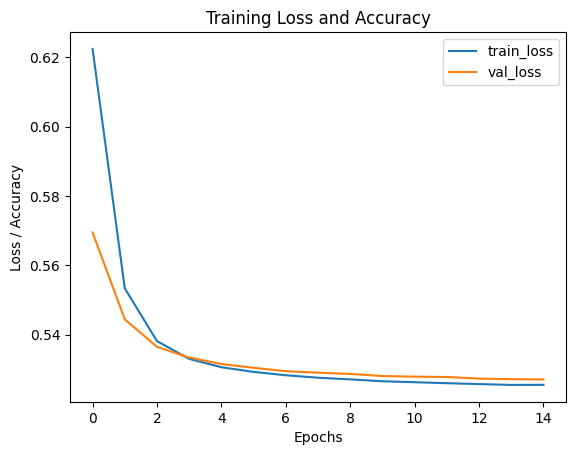


--- BƯỚC 5: KIỂM TRA KẾT QUẢ TÁI TẠO ẢNH CỦA AI ---
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step


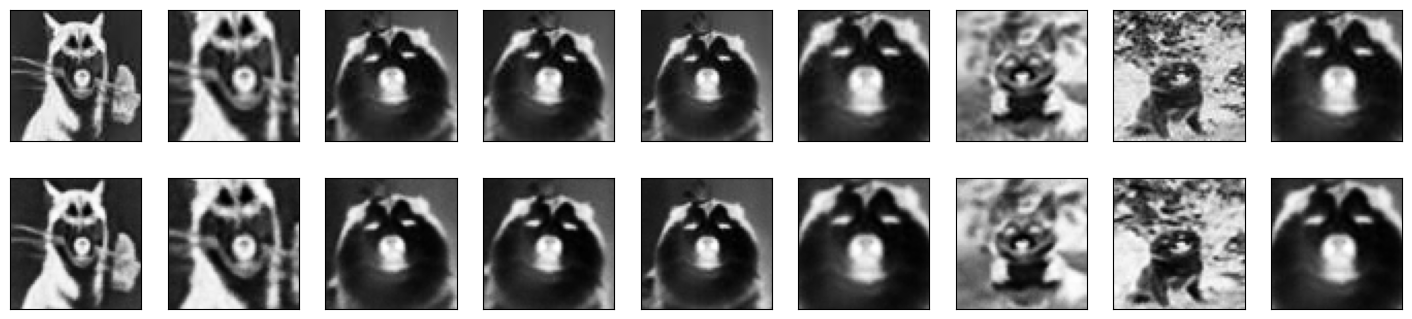

In [33]:
# =====================================================================
# 1. CÀI ĐẶT THƯ VIỆN & TẢI/GIẢI NÉN DỮ LIỆU
# =====================================================================
# !pip install Augmentor

import os
import glob
import zipfile
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
from google.colab import files

# print("--- BƯỚC 1: TẢI FILE ZIP CHỨA 21 ẢNH GỐC LÊN COLAB ---")
# uploaded = files.upload()
# zip_name = list(uploaded.keys())[0]

# dir_path = 'data/moalla-dataset'
# conv_path = 'data/conv'
# os.makedirs(dir_path, exist_ok=True)

# with zipfile.ZipFile(zip_name, 'r') as zip_ref:
#     for member in zip_ref.infolist():
#         if member.is_dir():
#             continue
#         member.filename = os.path.basename(member.filename)
#         if member.filename.startswith('.') or member.filename == "":
#             continue
#         zip_ref.extract(member, dir_path)
# print(f"🎉 Đã giải nén sạch sẽ toàn bộ ảnh gốc vào: {dir_path}\n")


# =====================================================================
# 2. ĐỊNH NGHĨA CÁC HÀM XỬ LÝ ẢNH
# =====================================================================
def get_pixel(image: Image.Image, i: int, j: int):
    return image.getpixel((i, j))

def change_image_background(orig_dir_path, target_conv_path):
    if not os.path.exists(target_conv_path):
        os.makedirs(target_conv_path)

    extensions = ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']
    image_paths = []
    for ext in extensions:
        image_paths.extend(glob.glob(os.path.join(orig_dir_path, ext)))

    print(f"Tìm thấy {len(image_paths)} hình ảnh gốc để chuyển đổi nền.")

    for img_path in tqdm(image_paths, desc="Đang đảo màu nền ảnh"):
        try:
            img = Image.open(img_path).convert('L').resize((64, 64))
            pixels = img.load()
            for i in range(img.size[0]):
                for j in range(img.size[1]):
                    pixels[i, j] = 255 - pixels[i, j]

            filename = os.path.basename(img_path)
            img.save(os.path.join(target_conv_path, filename))
        except Exception as e:
            print(f"Lỗi file {img_path}: {e}")

import Augmentor
def create_augmentor_pipeline(dirpath):
    p = Augmentor.Pipeline(dirpath)
    p.rotate(probability=0.7, max_left_rotation=10, max_right_rotation=10)
    p.zoom(probability=0.5, min_factor=1.1, max_factor=1.5)
    return p

def load_data(dir_path):
    data_list = []
    extensions = ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']
    image_paths = []
    for ext in extensions:
        image_paths.extend(glob.glob(os.path.join(dir_path, ext)))

    print(f"Đang load {len(image_paths)} ảnh vào bộ nhớ...")
    for img_path in tqdm(image_paths, desc="Loading data"):
        try:
            img = Image.open(img_path).convert('L')
            data_list.append(np.array(img))
        except Exception as e:
            pass
    return data_list


# =====================================================================
# 3. THỰC THI TIỀN XỬ LÝ VÀ CHUẨN HÓA DỮ LIỆU
# =====================================================================
print("\n--- BƯỚC 2: TIỀN XỬ LÝ & TĂNG CƯỜNG DỮ LIỆU ---")
change_image_background(dir_path, conv_path)

# Tạo 1000 ảnh tăng cường
p = create_augmentor_pipeline(conv_path)
p.sample(1000)

# Load dữ liệu từ thư mục output
augmentor_dir_path = os.path.join(conv_path, 'output')
data = load_data(augmentor_dir_path)

# Chia tập dữ liệu 80% Train, 20% Test
from sklearn.model_selection import train_test_split
train_data, test_data, _, _ = train_test_split(data, data, test_size=0.2, random_state=42)
train_data = np.array(train_data)
test_data = np.array(test_data)

# Chuẩn hóa pixel về khoảng [0, 1] và Reshape
normalized_train_data = train_data.astype('float32') / 255.0
normalized_test_data = test_data.astype('float32') / 255.0

normalized_train_data = np.expand_dims(normalized_train_data, axis=-1)
normalized_test_data = np.expand_dims(normalized_test_data, axis=-1)

print('\nQuá trình chuẩn hóa và định hình lại đã hoàn tất.')
print(f'Hình dạng tập Train = {normalized_train_data.shape}')
print(f'Hình dạng tập Test = {normalized_test_data.shape}\n')


# =====================================================================
# 4. ĐỊNH NGHĨA MODEL AUTOENCODER (ENCODER + DECODER)
# =====================================================================
print("--- BƯỚC 3: XÂY DỰNG MẠNG AUTOENCODER ---")
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Conv2D, Flatten, Reshape, Conv2DTranspose
from tensorflow.keras.models import Model

image_width = 64
image_height = 64
n_epochs = 15
batch_size = 128

# --- 4.1 ĐỊNH NGHĨA BỘ MÃ HÓA (ENCODER) ---
input_img = Input(shape=(image_width, image_height, 1), name='encoder_input')
x = Conv2D(32, (3, 3), activation='relu', strides=2, padding='same')(input_img) # -> Thu nhỏ về (None, 32, 32, 32)
x = Conv2D(64, (3, 3), activation='relu', strides=2, padding='same')(x)         # -> Thu nhỏ về (None, 16, 16, 64)
x = Conv2D(128, (3, 3), activation='relu', strides=2, padding='same')(x)        # -> Thu nhỏ về (None, 8, 8, 128)

# Đây là kích thước khối 3D thấp nhất: (8, 8, 128)
target_shape = (8, 8, 128)

x = Flatten()(x)
encoded = Dense(128, name='latent_space')(x) # Nén xuống không gian ẩn 128 chiều

encoder = Model(input_img, encoded, name='encoder')
print("\n--- Kiến trúc bộ mã hóa (Encoder) ---")
encoder.summary()


# --- 4.2 ĐỊNH NGHĨA BỘ GIẢI MÃ (DECODER) ---
encoded_input = Input(shape=(128,), name='decoder_input')

# Ép kiểu int để sửa lỗi units, dùng target_shape tường minh
x = Dense(int(np.prod(target_shape)))(encoded_input)
x = Reshape(target_shape)(x) # Khối xuất phát ban đầu: (8, 8, 128)

# Tầng 1: Phóng từ 8x8 lên 16x16
x = Conv2DTranspose(64, (3, 3), activation='relu', strides=2, padding='same')(x)

# Tầng 2: Phóng từ 16x16 lên 32x32
x = Conv2DTranspose(32, (3, 3), activation='relu', strides=2, padding='same')(x)

# Tầng 3 (ĐẦU RA): SỬA TẠI ĐÂY - Thêm strides=2 để phóng từ 32x32 lên ĐÚNG 64x64
decoder_output = Conv2DTranspose(1, (3, 3), activation='sigmoid', strides=2, padding='same')(x)

decoder = Model(encoded_input, decoder_output, name='decoder')
print("\n--- Kiến trúc bộ giải mã (Decoder) ---")
decoder.summary()


# --- 4.3 GHÉP NỐI THÀNH AUTOENCODER TỔNG THỂ ---
autoencoder_output = decoder(encoder(input_img))
autoencoder = Model(input_img, autoencoder_output, name="autoencoder")

print("\n--- Kiến trúc mô hình Autoencoder tổng thể ---")
autoencoder.summary()


# =====================================================================
# 5. HUẤN LUYỆN VÀ VẼ ĐỒ THỊ LOSS
# =====================================================================
print("\n--- BƯỚC 4: TIẾN HÀNH HUẤN LUYỆN AUTOENCODER ---")
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

h = autoencoder.fit(
    normalized_train_data, normalized_train_data,
    epochs=n_epochs,
    batch_size=batch_size,
    shuffle=True,
    validation_data=(normalized_test_data, normalized_test_data),
    callbacks=[TensorBoard(log_dir='/tmp/autoencoder')]
)

# Vẽ biểu đồ tổn thất huấn luyện và xác thực
N = np.arange(0, n_epochs)
plt.figure()
plt.plot(N, h.history['loss'], label='train_loss')
plt.plot(N, h.history['val_loss'], label='val_loss')
plt.title('Training Loss and Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss / Accuracy')
plt.legend(loc='upper right')
plt.show()


# =====================================================================
# 6. HIỂN THỊ TRỰC QUAN KẾT QUẢ TÁI TẠO ẢNH
# =====================================================================
print("\n--- BƯỚC 5: KIỂM TRA KẾT QUẢ TÁI TẠO ẢNH CỦA AI ---")
def visualize(model, X_test, n_samples):
    """ Hiển thị trực quan các hình ảnh gốc và hình ảnh được tái tạo """
    reconstructed_images = model.predict(X_test)

    plt.figure(figsize=(20, 4))
    for i in range(1, n_samples):
        # Sử dụng len(X_test) thay vì số cứng 2000 để tuyệt đối an toàn không bị out of index
        rand_num = np.random.randint(0, len(X_test))

        # Để hiển thị hình ảnh gốc
        ax = plt.subplot(2, 10, i)
        plt.imshow(X_test[rand_num].reshape(image_width, image_width), cmap='gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

        # Để hiển thị hình ảnh được tái tạo
        ax = plt.subplot(2, 10, i + 10)
        plt.imshow(reconstructed_images[rand_num].reshape(image_width, image_width), cmap='gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    plt.show()

# Vẽ biểu đồ `n_samples` hình ảnh
n_samples = 10
visualize(autoencoder, normalized_test_data, n_samples)

In [ ]:
# =====================================================================
# 1. CÀI ĐẶT THƯ VIỆN & TẢI/GIẢI NÉN DỮ LIỆU
# =====================================================================
!pip install Augmentor moviepy

import os
import glob
import zipfile
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
from google.colab import files

# print("--- BƯỚC 1: TẢI FILE ZIP CHỨA 21 ẢNH GỐC LÊN COLAB ---")
# uploaded = files.upload()
# zip_name = list(uploaded.keys())[0]

# dir_path = 'data/moalla-dataset'
# conv_path = 'data/conv'
# os.makedirs(dir_path, exist_ok=True)

# with zipfile.ZipFile(zip_name, 'r') as zip_ref:
#     for member in zip_ref.infolist():
#         if member.is_dir():
#             continue
#         member.filename = os.path.basename(member.filename)
#         if member.filename.startswith('.') or member.filename == "":
#             continue
#         zip_ref.extract(member, dir_path)
# print(f"🎉 Đã giải nén sạch sẽ toàn bộ ảnh gốc vào: {dir_path}\n")


# =====================================================================
# 2. ĐỊNH NGHĨA CÁC HÀM XỬ LÝ & TĂNG CƯỜNG ẢNH
# =====================================================================
def get_pixel(image: Image.Image, i: int, j: int):
    return image.getpixel((i, j))

def change_image_background(orig_dir_path, target_conv_path):
    if not os.path.exists(target_conv_path):
        os.makedirs(target_conv_path)

    extensions = ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']
    image_paths = []
    for ext in extensions:
        image_paths.extend(glob.glob(os.path.join(orig_dir_path, ext)))

    print(f"Tìm thấy {len(image_paths)} hình ảnh gốc để chuyển đổi nền.")

    for img_path in tqdm(image_paths, desc="Đang đảo màu nền ảnh"):
        try:
            img = Image.open(img_path).convert('L').resize((64, 64))
            pixels = img.load()
            for i in range(img.size[0]):
                for j in range(img.size[1]):
                    pixels[i, j] = 255 - pixels[i, j]

            filename = os.path.basename(img_path)
            img.save(os.path.join(target_conv_path, filename))
        except Exception as e:
            print(f"Lỗi file {img_path}: {e}")

import Augmentor
def create_augmentor_pipeline(dirpath):
    p = Augmentor.Pipeline(dirpath)
    p.rotate(probability=0.7, max_left_rotation=10, max_right_rotation=10)
    p.zoom(probability=0.5, min_factor=1.1, max_factor=1.5)
    return p

def load_data(dir_path):
    data_list = []
    extensions = ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']
    image_paths = []
    for ext in extensions:
        image_paths.extend(glob.glob(os.path.join(dir_path, ext)))

    print(f"Đang load {len(image_paths)} ảnh vào bộ nhớ...")
    for img_path in tqdm(image_paths, desc="Loading data"):
        try:
            img = Image.open(img_path).convert('L')
            data_list.append(np.array(img))
        except Exception as e:
            pass
    return data_list


# =====================================================================
# 3. THỰC THI TIỀN XỬ LÝ VÀ CHUẨN HÓA DỮ LIỆU
# =====================================================================
print("\n--- BƯỚC 2: TIỀN XỬ LÝ & TĂNG CƯỜNG DỮ LIỆU ---")
change_image_background(dir_path, conv_path)

# Tạo 1000 ảnh tăng cường (Augmentation)
p = create_augmentor_pipeline(conv_path)
p.sample(1000)

# Load dữ liệu từ thư mục output
augmentor_dir_path = os.path.join(conv_path, 'output')
data = load_data(augmentor_dir_path)

# Chia tập dữ liệu 80% Train, 20% Test
from sklearn.model_selection import train_test_split
train_data, test_data, _, _ = train_test_split(data, data, test_size=0.2, random_state=42)
train_data = np.array(train_data)
test_data = np.array(test_data)

# Chuẩn hóa pixel về khoảng [0, 1] và mở rộng số kênh màu thành (64, 64, 1)
normalized_train_data = train_data.astype('float32') / 255.0
normalized_test_data = test_data.astype('float32') / 255.0

normalized_train_data = np.expand_dims(normalized_train_data, axis=-1)
normalized_test_data = np.expand_dims(normalized_test_data, axis=-1)

print('\nQuá trình chuẩn hóa và định hình lại đã hoàn tất.')
print(f'Hình dạng tập Train = {normalized_train_data.shape}')
print(f'Hình dạng tập Test = {normalized_test_data.shape}\n')


# =====================================================================
# 4. XÂY DỰNG MÔ HÌNH VARIATIONAL AUTOENCODER (VAE)
# =====================================================================
print("--- BƯỚC 3: XÂY DỰNG MẠNG VARIATIONAL AUTOENCODER (VAE) ---")
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Conv2D, Flatten, Reshape, Conv2DTranspose, BatchNormalization, Lambda, Layer
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K
from tensorflow.keras.losses import binary_crossentropy
from tensorflow.keras.callbacks import TensorBoard

image_width = 64
image_height = 64
latent_dim = 2
n_epochs = 30
batch_size = 128
num_channels = 1

# --- Thủ thuật tái tham số hóa (Reparameterization Trick) ---
def sample_z(args):
    mu, sigma = args
    batch = K.shape(mu)[0]
    dim = K.int_shape(mu)[1]
    eps = K.random_normal(shape=(batch, dim))
    return mu + K.exp(sigma / 2) * eps

# --- TẦNG TÙY CHỈNH TÍNH VAE LOSS (GIẢI QUYẾT TRIỆT ĐỂ LỖI KERAS TENSOR) ---
class VAELossLayer(Layer):
    def __init__(self, **kwargs):
        super(VAELossLayer, self).__init__(**kwargs)

    def call(self, inputs_all):
        x_true, x_pred, mu_val, sigma_val = inputs_all

        # 1. Tổn thất tái tạo (Reconstruction Loss)
        recon_loss = binary_crossentropy(K.flatten(x_true), K.flatten(x_pred)) * image_width * image_height

        # 2. Tổn thất phân kỳ KL (KL Divergence Loss)
        kl_loss = 1 + sigma_val - K.square(mu_val) - K.exp(sigma_val)
        kl_loss = K.sum(kl_loss, axis=-1)
        kl_loss *= -0.5

        # Tổng tổn thất trung bình
        total_loss = K.mean(recon_loss + kl_loss)

        # Đăng ký tổn thất này vào mô hình
        self.add_loss(total_loss)

        # Trả về x_pred để làm đầu ra tiếp theo của mạng mạng nếu cần
        return x_pred

# --- 4.1 ĐỊNH NGHĨA BỘ MÃ HÓA (ENCODER) ---
encoder_inputs = Input(shape=(image_width, image_height, 1), name='encoder_input')
x = Conv2D(32, (3, 3), activation='relu', strides=2, padding='same')(encoder_inputs)
x = BatchNormalization()(x)
x = Conv2D(64, (3, 3), activation='relu', strides=2, padding='same')(x)
x = BatchNormalization()(x)

conv_shape = K.int_shape(x)

x = Flatten()(x)
x = Dense(16, activation='relu')(x)
x = BatchNormalization()(x)

mu = Dense(latent_dim, name='latent_mu')(x)
sigma = Dense(latent_dim, name='latent_sigma')(x)

z = Lambda(sample_z, output_shape=(latent_dim,), name='z')([mu, sigma])

encoder = Model(encoder_inputs, [mu, sigma, z], name='encoder')
print("\n--- Kiến trúc Bộ mã hóa (Encoder) ---")
encoder.summary()


# --- 4.2 ĐỊNH NGHĨA BỘ GIẢI MÃ (DECODER) ---
d_i = Input(shape=(latent_dim,), name='decoder_input')
x = Dense(conv_shape[1] * conv_shape[2] * conv_shape[3], activation='relu')(d_i)
x = BatchNormalization()(x)
x = Reshape((conv_shape[1], conv_shape[2], conv_shape[3]))(x)

cx = Conv2DTranspose(32, (3, 3), strides=2, padding='same', activation='relu')(x)
cx = BatchNormalization()(cx)
cx = Conv2DTranspose(16, (3, 3), strides=2, padding='same', activation='relu')(cx)
cx = BatchNormalization()(cx)
decoder_outputs = Conv2DTranspose(1, (3, 3), activation='sigmoid', padding='same', name='decoder_output')(cx)

decoder = Model(d_i, decoder_outputs, name='decoder')
print("\n--- Kiến trúc Bộ giải mã (Decoder) ---")
decoder.summary()


# --- 4.3 GHÉP NỐI VÀ ÁP DỤNG LAYER TÍNH LOSS CHO VAE ---
vae_outputs = decoder(encoder(encoder_inputs)[2])

# Truyền tất cả các Tensor cần thiết vào VAELossLayer để xử lý nội bộ
final_outputs = VAELossLayer(name='vae_loss_layer')([encoder_inputs, vae_outputs, mu, sigma])

# Tạo model tổng thể từ đầu vào ban đầu đến đầu ra cuối của Layer Loss
vae = Model(encoder_inputs, final_outputs, name='vae')

# Biên dịch mô hình (Vì loss đã được add qua Layer, ta không cần truyền tham số loss= nữa)
vae.compile(optimizer='adam')

print("\n--- Kiến trúc Mô hình VAE Tổng thể ---")
vae.summary()


# =====================================================================
# 5. HUẤN LUYỆN VÀ VẼ BIỂU ĐỒ LOSS
# =====================================================================
print("\n--- BƯỚC 4: TIỀN HÀNH HUẤN LUYỆN MẠNG VAE ---")
h = vae.fit(
    normalized_train_data,
    epochs=n_epochs,
    batch_size=batch_size,
    validation_data=(normalized_test_data, None),
    callbacks=[TensorBoard(log_dir='/tmp/autoencoder')]
)

# Vẽ biểu đồ Loss huấn luyện
N = np.arange(0, n_epochs)
plt.figure(figsize=(8, 4))
plt.plot(N, h.history['loss'], label='train_loss')
plt.plot(N, h.history['val_loss'], label='val_loss')
plt.title('VAE Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()


# =====================================================================
# 6. HIỂN THỊ KHÔNG GIAN TIỀM ẨN (LATENT SPACE RECONSTRUCTION GRID)
# =====================================================================
print("\n--- BƯỚC 5: HIỂN THỊ BẢN ĐỒ KHÔNG GIAN TIỀM ẨN 2D ---")
def viz_decoded(decoder, num_samples=10):
    figure = np.zeros((image_width * num_samples, image_height * num_samples))
    grid_x = np.linspace(-3, 3, num_samples)
    grid_y = np.linspace(-3, 3, num_samples)[::-1]

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = np.array([[xi, yi]])
            x_decoded = decoder.predict(z_sample, verbose=0)
            digit = x_decoded[0].reshape(image_width, image_height)
            figure[i * image_width: (i + 1) * image_width, j * image_height: (j + 1) * image_height] = digit

    plt.figure(figsize=(10, 10))
    start_range = image_width // 2
    end_range = num_samples * image_width + start_range
    pixel_range = np.arange(start_range, end_range, image_width)

    plt.xticks(pixel_range, np.round(grid_x, 1))
    plt.yticks(pixel_range, np.round(grid_y, 1))
    plt.xlabel('z - dim 1')
    plt.ylabel('z - dim 2')
    plt.imshow(figure, cmap='gray')
    plt.show()

viz_decoded(decoder, num_samples=10)


# =====================================================================
# 7. TẠO ẢNH ĐỘNG BIẾN HÌNH CHỮ (MORPHING CHARACTER GIF)
# =====================================================================
print("\n--- BƯỚC 6: TẠO VIDEO/GIF BIẾN ĐỔI CHỮ (MORPHING CHỮ CÁI) ---")
import moviepy.editor as mpy

def load_image(file_path):
    img = Image.open(file_path).convert('L').resize((64, 64))
    return np.array(img)

def generate_morph_images(image_1, image_2, encoder, decoder, n_steps):
    # Chuẩn hóa ảnh đầu vào
    img1_norm = image_1.astype('float32') / 255.0
    img2_norm = image_2.astype('float32') / 255.0

    # Dự đoán tọa độ trong không gian tiềm ẩn z (lấy phần tử chỉ số [2] là z)
    vec1 = encoder.predict(img1_norm.reshape(-1, image_width, image_height, 1), verbose=0)[2]
    vec2 = encoder.predict(img2_norm.reshape(-1, image_width, image_height, 1), verbose=0)[2]

    morph_vecs = []
    for i in range(n_steps):
        alpha = i / (n_steps - 1)
        # Nội suy tuyến tính giữa vector z1 và vector z2
        interp_vec = (1 - alpha) * vec1 + alpha * vec2
        morph_vecs.append(interp_vec)

    return [decoder.predict(vec, verbose=0) for vec in morph_vecs]

def animate_morph_images(image_1, image_2, encoder, decoder, n_steps, loop=True):
    # Tạo chuỗi các khung hình nội suy, chuyển đổi khoảng [0, 1] về màu RGB 3 kênh [0, 255] cho Moviepy
    generated = generate_morph_images(image_1, image_2, encoder, decoder, n_steps)
    morph_images = []
    for f in generated:
        img_frame = np.multiply(f[0], 255).astype(np.uint8)
        img_frame_rgb = np.stack([img_frame.squeeze()] * 3, axis=-1) # Chuyển sang 3 kênh màu RGB
        morph_images.append(img_frame_rgb)

    if loop:
        morph_images = (
            int(n_steps / 5) * [morph_images[0]]
            + morph_images
            + int(n_steps / 5) * [morph_images[-1]]
            + morph_images[::-1]
        )
    return mpy.ImageSequenceClip(morph_images, fps=25)

# --- Thực thi xuất File ảnh GIF ---
# Quét tìm ngẫu nhiên 2 file ảnh đã đảo nền trong thư mục conv_path để làm cặp biến hình
processed_images = glob.glob(os.path.join(conv_path, '*.png')) + glob.glob(os.path.join(conv_path, '*.jpg'))

if len(processed_images) >= 2:
    img1_path = processed_images[0]
    img2_path = processed_images[1]

    img1 = load_image(img1_path)
    img2 = load_image(img2_path)

    n_steps = 90
    clip = animate_morph_images(img1, img2, encoder, decoder, n_steps)

    # Ghi thành file GIF để xem thành quả trực quan
    output_gif = '7to10.gif'
    clip.write_gif(output_gif, fps=25)
    print(f"\n🎉 Hoàn thành! Đã tạo thành công file ảnh động biến đổi ký tự tại: {output_gif}")
else:
    print("⚠️ Cảnh báo: Không tìm đủ 2 ảnh trong thư mục đầu ra để làm hiệu ứng biến hình.")


--- BƯỚC 2: TIỀN XỬ LÝ & TĂNG CƯỜNG DỮ LIỆU ---
Tìm thấy 5 hình ảnh gốc để chuyển đổi nền.


Đang đảo màu nền ảnh: 100%|██████████| 5/5 [00:00<00:00, 420.42it/s]


Initialised with 5 image(s) found.
Output directory set to data/conv/output.

Processing <PIL.Image.Image image mode=L size=64x64 at 0x78A74C436F60>: 100%|██████████| 1000/1000 [00:02<00:00, 413.53 Samples/s]


Đang load 14000 ảnh vào bộ nhớ...


...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 32, 32,    │        320 │ encoder_input[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 16, 16,    │     18,496 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_17[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_7 (Flatten) │ (None, 16384)     │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 16)        │    262,160 │ flatten_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder             │ [(None, 2),       │    281,492 │ encoder_input[0]… │
│ (Functional)        │ (None, 2), (None, │            │                   │
│                     │ 2)]               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16)        │         64 │ dense_7[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder             │ (None, 64, 64, 1) │    138,113 │ encoder[0][2]     │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ latent_mu (Dense)   │ (None, 2)         │         34 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ latent_sigma        │ (None, 2)         │         34 │ batch_normalizat… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_loss_layer      │ (None, 64, 64, 1) │          0 │ encoder_input[0]… │
│ (VAELossLayer)      │                   │            │ decoder[0][0],    │
│                     │                   │            │ latent_mu[0][0],  │
│                     │                   │            │ latent_sigma[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 419,605 (1.60 MB)

 Trainable params: 386,517 (1.47 MB)

 Non-trainable params: 33,088 (129.25 KB)


--- BƯỚC 4: TIỀN HÀNH HUẤN LUYỆN MẠNG VAE ---
Epoch 1/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - loss: 2640.8770 - val_loss: 2788.7104
Epoch 2/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - loss: 2443.1626 - val_loss: 2765.6523
Epoch 3/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - loss: 2404.0417 - val_loss: 2672.5747
Epoch 4/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - loss: 2370.2981 - val_loss: 2516.0383
Epoch 5/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - loss: 2350.3945 - val_loss: 2417.7085
Epoch 6/30
60/88 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - loss: 2347.0988